<a href="https://colab.research.google.com/github/Ayushmanity/PINN/blob/main/Sigma_Epsilon.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
!pip install deepxde

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 195.4/195.4 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.8/107.8 kB 8.2 MB/s eta 0:00:00


In [4]:
import os
os.environ["DDE_BACKEND"]="pytorch"
import torch
import deepxde as dde
import numpy as np

Using backend: pytorch
Other supported backends: tensorflow.compat.v1, tensorflow, jax, paddle.
paddle supports more examples now and is recommended.


In [5]:
E_val = 210e9
nu_val = 0.3
sigma_0 = 100e6
R = 0.2
L = 1.0
E_scale = E_val
E = E_val / E_scale
nu = nu_val
P_0 = sigma_0 / E_scale

In [6]:
def elastic_pde(x,y):
  #Displacement calculation
  u=y[:,0:1]
  v=y[:,1:2]
  #strain calculation
  du_x=dde.grad.jacobian(y,x,i=0,j=0)
  du_y=dde.grad.jacobian(y,x,i=0,j=1)
  dv_x = dde.grad.jacobian(y, x, i=1, j=0)
  dv_y = dde.grad.jacobian(y, x, i=1, j=1)

  factor = E / (1 - nu**2)
  sigma_xx = factor * (du_x + nu * dv_y)
  sigma_yy = factor * (dv_y + nu * du_x)
  tau_xy = (E / (2 * (1 + nu))) * (du_y + dv_x)

  # Second derivatives (Equilibrium Residuals)
  dsxx_x = dde.grad.jacobian(sigma_xx, x, i=0, j=0)
  dsxy_y = dde.grad.jacobian(tau_xy, x, i=0, j=1)
  dsxy_x = dde.grad.jacobian(tau_xy, x, i=0, j=0)
  dsyy_y = dde.grad.jacobian(sigma_yy, x, i=0, j=1)

  # Momentum Equilibrium equations: div(Sigma) = 0
  res_x = dsxx_x + dsxy_y
  res_y = dsxy_x + dsyy_y

  return [res_x, res_y]

In [7]:
rectangle=dde.geometry.Rectangle(xmin=[0,0],xmax=[L,L])
disk=dde.geometry.Disk([0,0],R)
geom=dde.geometry.CSGDifference(rectangle,disk)


In [8]:
def left_boundary(x, on_boundary):
  return on_boundary and np.isclose(x[0], 0)

def right_boundary(x, on_boundary):
  return on_boundary and np.isclose(x[0], L)

In [9]:
bc_left = dde.icbc.DirichletBC(geom, lambda x: 0,left_boundary , component=0)

In [10]:
def right_traction_bc(x, y, X):
    du_x = dde.grad.jacobian(y, x, i=0, j=0)
    dv_y = dde.grad.jacobian(y, x, i=1, j=1)
    sigma_xx = (E / (1 - nu**2)) * (du_x + nu * dv_y)
    return sigma_xx - P_0

In [11]:
bc_right = dde.icbc.OperatorBC(geom, right_traction_bc, right_boundary)
def boundary_hole(x, on_boundary):
    r = np.sqrt(x[0]**2 + x[1]**2)
    return on_boundary and np.isclose(r, R)

In [12]:
def hole_traction_bc(x, y, X):
    u, v = y[:, 0:1], y[:, 1:2]
    du_x = dde.grad.jacobian(y, x, i=0, j=0)
    du_y = dde.grad.jacobian(y, x, i=0, j=1)
    dv_x = dde.grad.jacobian(y, x, i=1, j=0)
    dv_y = dde.grad.jacobian(y, x, i=1, j=1)

    factor = E / (1 - nu**2)
    s_xx = factor * (du_x + nu * dv_y)
    s_yy = factor * (dv_y + nu * du_x)
    s_xy = (E / (2 * (1 + nu))) * (du_y + dv_x)

    nx = -x[:, 0:1] / R
    ny = -x[:, 1:2] / R

    tx = s_xx * nx + s_xy * ny
    ty = s_xy * nx + s_yy * ny
    return torch.cat([tx, ty], dim=1)

bc_hole = dde.icbc.OperatorBC(geom, hole_traction_bc, boundary_hole)

In [13]:
data = dde.data.PDE(
    geom,
    elastic_pde,
    [bc_left, bc_right, bc_hole],
    num_domain=2500,
    num_boundary=400,
    num_test=1000
)

In [14]:
net = dde.nn.FNN([2] + [64] * 4 + [2], "tanh", "Glorot normal")
model = dde.Model(data, net)
print("FYMN")
model.compile("adam", lr=1e-3, loss_weights=[1.0, 1.0, 10.0, 10.0, 10.0])
losshistory, train_state = model.train(iterations=5000)


FYMN
Compiling model...
'compile' took 6.262861 s

Training model...

Step      Train loss                                            Test loss                                             Test metric
0         [6.38e-03, 7.01e-03, 1.42e-01, 9.70e-02, 1.86e-01]    [6.26e-03, 7.41e-03, 1.42e-01, 9.70e-02, 1.86e-01]    []  
1000      [6.65e-06, 1.29e-05, 4.13e-05, 6.21e-04, 7.30e-04]    [7.05e-06, 1.33e-05, 4.13e-05, 6.21e-04, 7.30e-04]    []  
2000      [8.83e-07, 6.20e-07, 1.82e-07, 4.72e-07, 7.92e-08]    [7.87e-07, 5.79e-07, 1.82e-07, 4.72e-07, 7.92e-08]    []  
3000      [2.61e-07, 1.25e-07, 1.02e-07, 1.26e-07, 1.42e-08]    [2.12e-07, 1.12e-07, 1.02e-07, 1.26e-07, 1.42e-08]    []  
4000      [2.28e-07, 1.42e-07, 9.77e-08, 2.47e-06, 1.19e-06]    [2.08e-07, 1.35e-07, 9.77e-08, 2.47e-06, 1.19e-06]    []  
5000      [8.51e-08, 6.14e-08, 3.93e-08, 7.55e-08, 7.95e-09]    [7.36e-08, 5.47e-08, 3.93e-08, 7.55e-08, 7.95e-09]    []  

Best model at step 5000:
  train loss: 2.69e-07
  test loss: 

In [15]:
print("KYFMSOIGFYDM")
model.compile("L-BFGS")
losshistory, train_state = model.train()
model.save("stress_pinn_model")

KYFMSOIGFYDM
Compiling model...
'compile' took 0.001368 s

Training model...

Step      Train loss                                            Test loss                                             Test metric
5000      [8.51e-08, 6.14e-08, 3.93e-09, 7.55e-09, 7.95e-10]    [7.36e-08, 5.47e-08, 3.93e-09, 7.55e-09, 7.95e-10]    []  
5156      [9.08e-09, 5.35e-09, 6.42e-11, 3.68e-09, 5.78e-10]    [7.15e-09, 4.65e-09, 6.42e-11, 3.68e-09, 5.78e-10]    []  

Best model at step 5156:
  train loss: 1.87e-08
  test loss: 1.61e-08
  test metric: []

'train' took 46.819799 s



'stress_pinn_model-5156.pt'

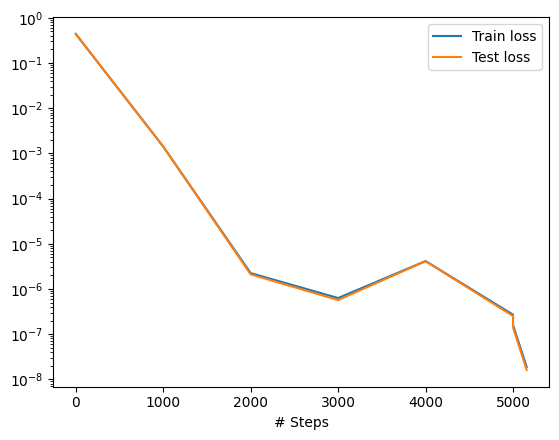

In [18]:
dde.utils.plot_loss_history(losshistory)

/tmp/ipykernel_1163/2954959538.py:61: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  SXX_grid[j, i] = s_xx_pred[k]
/tmp/ipykernel_1163/2954959538.py:62: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  SYY_grid[j, i] = s_yy_pred[k]
/tmp/ipykernel_1163/2954959538.py:63: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  TXY_grid[j, i] = t_xy_pred[k]


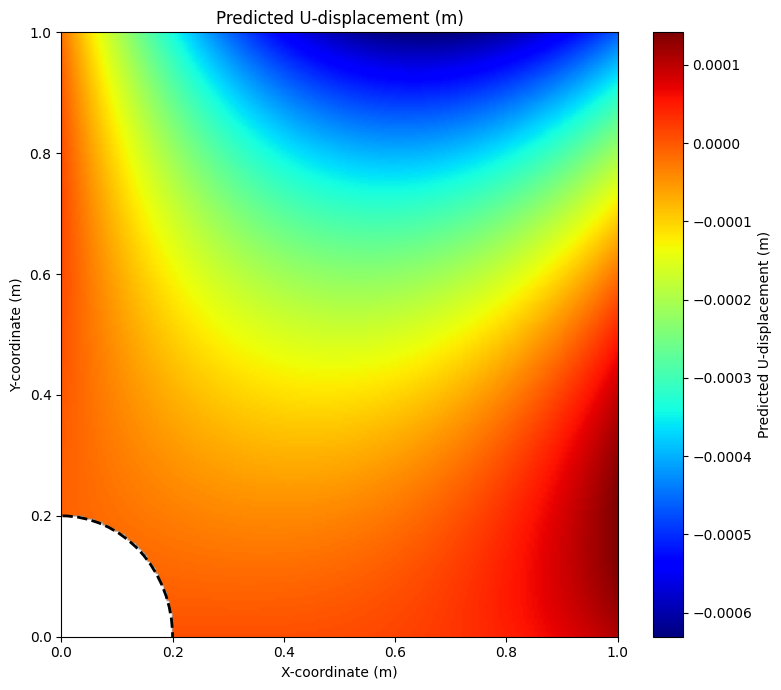

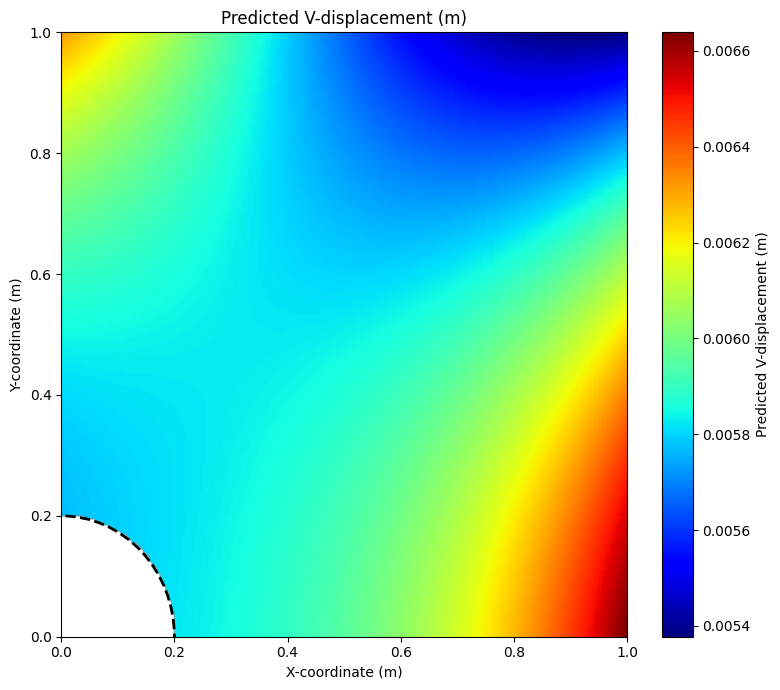

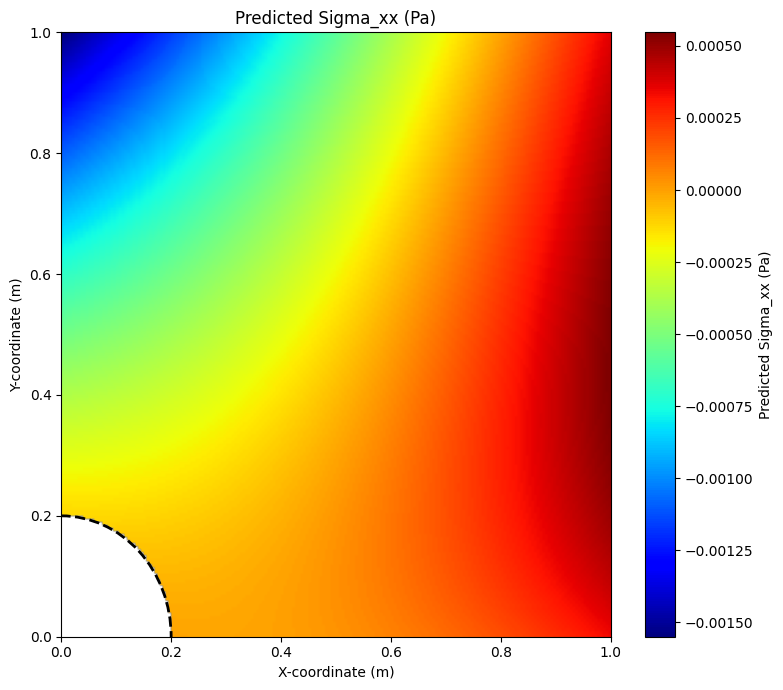

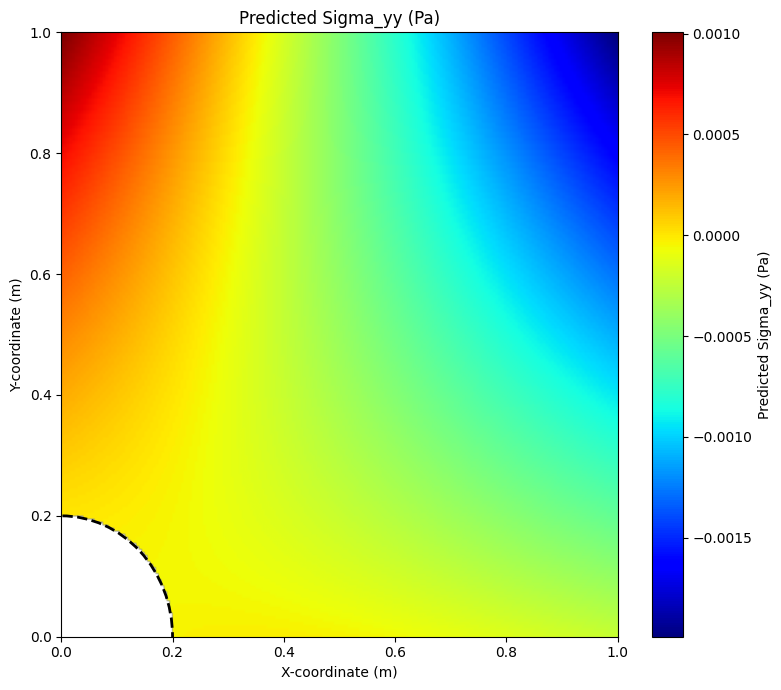

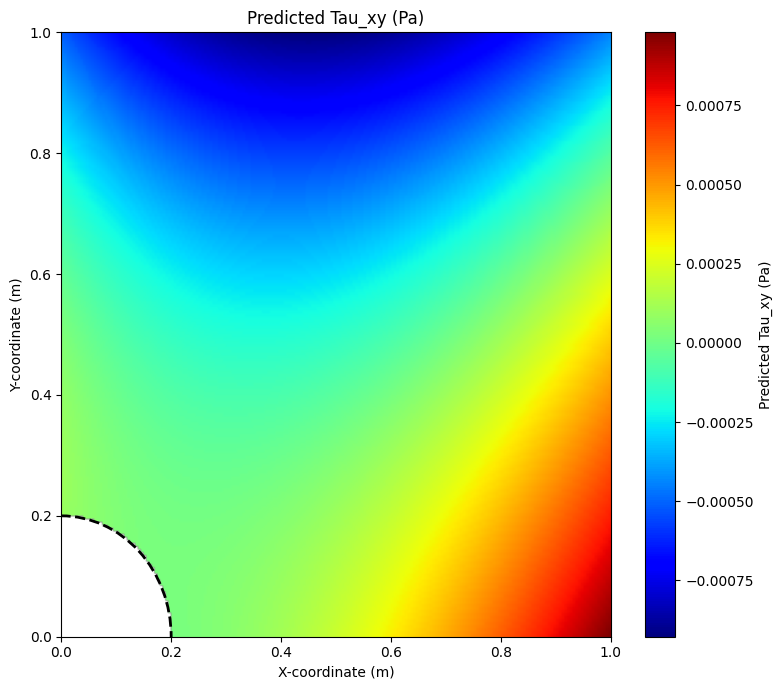

In [21]:
import matplotlib.pyplot as plt
import numpy as np


n_points = 200 #
x_coords = np.linspace(0, L, n_points)
y_coords = np.linspace(0, L, n_points)

X_plot = []
for x in x_coords:
    for y in y_coords:

        if not ((x - 0)**2 + (y - 0)**2 <= R**2):
            X_plot.append([x, y])
X_plot = np.array(X_plot)


pred_uv = model.predict(X_plot)
u_pred = pred_uv[:, 0]
v_pred = pred_uv[:, 1]


def calculate_stress_components(X, u, v, E, nu, model):


    X_torch = torch.tensor(X, dtype=torch.float32, requires_grad=True)
    pred_uv_torch = model.net(X_torch) # Get raw output from the neural network

    u_torch = pred_uv_torch[:, 0:1]
    v_torch = pred_uv_torch[:, 1:2]


    du_x = torch.autograd.grad(u_torch, X_torch, torch.ones_like(u_torch), create_graph=True)[0][:, 0:1]
    du_y = torch.autograd.grad(u_torch, X_torch, torch.ones_like(u_torch), create_graph=True)[0][:, 1:2]
    dv_x = torch.autograd.grad(v_torch, X_torch, torch.ones_like(v_torch), create_graph=True)[0][:, 0:1]
    dv_y = torch.autograd.grad(v_torch, X_torch, torch.ones_like(v_torch), create_graph=True)[0][:, 1:2]

    factor = E / (1 - nu**2)
    sigma_xx = factor * (du_x + nu * dv_y)
    sigma_yy = factor * (dv_y + nu * du_x)
    tau_xy = (E / (2 * (1 + nu))) * (du_y + dv_x)

    return sigma_xx.detach().numpy(), sigma_yy.detach().numpy(), tau_xy.detach().numpy()

s_xx_pred, s_yy_pred, t_xy_pred = calculate_stress_components(X_plot, u_pred, v_pred, E, nu, model)


U_grid = np.full((n_points, n_points), np.nan)
V_grid = np.full((n_points, n_points), np.nan)
SXX_grid = np.full((n_points, n_points), np.nan)
SYY_grid = np.full((n_points, n_points), np.nan)
TXY_grid = np.full((n_points, n_points), np.nan)


k = 0
for i, x in enumerate(x_coords):
    for j, y in enumerate(y_coords):
        if not ((x - 0)**2 + (y - 0)**2 <= R**2):
            U_grid[j, i] = u_pred[k]
            V_grid[j, i] = v_pred[k]
            SXX_grid[j, i] = s_xx_pred[k]
            SYY_grid[j, i] = s_yy_pred[k]
            TXY_grid[j, i] = t_xy_pred[k]
            k += 1


def plot_heatmap(data_grid, title, filename):
    fig = plt.figure(figsize=(8, 7))
    plt.imshow(data_grid, extent=[0, L, 0, L], origin='lower', cmap='jet', aspect='auto')
    plt.colorbar(label=title)
    plt.title(title)
    plt.xlabel('X-coordinate (m)')
    plt.ylabel('Y-coordinate (m)')
    plt.gca().add_patch(plt.Circle((0, 0), R, color='black', fill=False, linestyle='--', linewidth=2))
    plt.grid(False)
    plt.tight_layout()
    plt.show()
    return fig


fig_u = plot_heatmap(U_grid, 'Predicted U-displacement (m)', 'u_displacement.png')
fig_v = plot_heatmap(V_grid, 'Predicted V-displacement (m)', 'v_displacement.png')


fig_sxx = plot_heatmap(SXX_grid, 'Predicted Sigma_xx (Pa)', 'sigma_xx.png')
fig_syy = plot_heatmap(SYY_grid, 'Predicted Sigma_yy (Pa)', 'sigma_yy.png')
fig_txy = plot_heatmap(TXY_grid, 'Predicted Tau_xy (Pa)', 'tau_xy.png')
